In [9]:
pip install pydicom

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
pip install SimpleITK


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


In [ ]:
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

In [13]:
# Limit GPU memory usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.cuda.set_per_process_memory_fraction(0.5, device=0)
    torch.backends.cudnn.benchmark = True

print("Using device:", device)


Using device: cuda


In [14]:
PROJECT_ROOT = Path(r"E:\Study\Folder-for-everthing-need-to-use-from-PC-to-Laptop")

DATA_DIR = PROJECT_ROOT / "subset1"
ANNOTATION_FILE = PROJECT_ROOT / "annotations.csv"


In [15]:
mhd_files = sorted(DATA_DIR.glob("*.mhd"))

print(f"Found {len(mhd_files)} CT scans")
print(mhd_files[0])


Found 89 CT scans
E:\Study\Folder-for-everthing-need-to-use-from-PC-to-Laptop\subset1\1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163890911914061745866.mhd


In [16]:
import SimpleITK as sitk
import numpy as np 

mhd_path = r"E:\Study\usth\ml_med\subset1\1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163890911914061745866.mhd"

image = sitk.ReadImage(mhd_path)

volume = sitk.GetArrayFromImage(image)

print(type(volume))

print(volume.shape)

<class 'numpy.ndarray'>
(171, 512, 512)


In [17]:
spacing = image.GetSpacing()
origin = image.GetOrigin()

print("Spacing (x, y, z):", spacing)
print("Origin:", origin)


Spacing (x, y, z): (0.48828125, 0.48828125, 1.7999999523162842)
Origin: (-127.755859375, -277.755859375, -351.5)


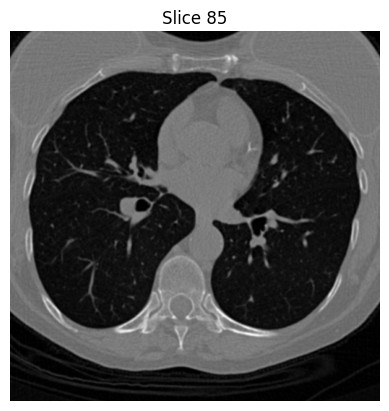

In [18]:
slice_id = volume.shape[0] // 2 

plt.imshow(volume[slice_id], cmap="gray")
plt.title(f"Slice {slice_id}")
plt.axis("off")
plt.show()


In [19]:
csv_path = r"E:\Study\usth\ml_med\subset1\1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163890911914061745866.mhd" 
df = pd.read_csv(csv_path)
df["label"] = 1

print(df.columns)
print(df.head())


Index(['ObjectType = Image', 'label'], dtype='object')
                    ObjectType = Image  label
0                            NDims = 3      1
1                    BinaryData = True      1
2       BinaryDataByteOrderMSB = False      1
3               CompressedData = False      1
4  TransformMatrix = 1 0 0 0 1 0 0 0 1      1


In [20]:
IMAGE_ROOT = r"E:\Study\usth\ml_med\subset1"
ANNOTATION_PATH = r"E:\Study\usth\ml_med\annotations.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [21]:
df = pd.read_csv(ANNOTATION_PATH)

def filter_existing_scans(df, image_root):
    existing = set(
        f.replace(".mhd", "")
        for f in os.listdir(image_root)
        if f.endswith(".mhd")
    )
    return df[df["seriesuid"].isin(existing)].reset_index(drop=True)

df = filter_existing_scans(df, IMAGE_ROOT)

print("Filtered annotations:", len(df))
print(df.head())


Filtered annotations: 128
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.104562737760... -124.834262  127.247155   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.106719103982...  -57.087180   74.259266   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...   42.574154   90.267552   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.114218724025... -127.532989  -29.607902   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.114218724025...   93.138882   -5.652615   

        coordZ  diameter_mm  
0  -473.064479    10.465854  
1  1790.494057    13.693566  
2   -84.811060     5.916174  
3  -253.697616     8.269325  
4  -213.910616     6.209760  


In [31]:
annotations = pd.read_csv(r"E:\Study\usth\ml_med\annotations.csv")

ct_dir = Path(r"E:\Study\Folder-for-everthing-need-to-use-from-PC-to-Laptop\subset1")

available_seriesuids = set(p.stem for p in ct_dir.glob("*.mhd"))

print(f"Found {len(available_seriesuids)} CT scans on disk")

annotations = annotations[annotations["seriesuid"].isin(available_seriesuids)]

print(f"Remaining annotations after filtering: {len(annotations)}")

Found 89 CT scans on disk
Remaining annotations after filtering: 128


In [23]:
def load_ct_volume(mhd_path):
    itk_img = sitk.ReadImage(mhd_path)
    volume = sitk.GetArrayFromImage(itk_img)  # (Z, Y, X)

    volume = volume.astype(np.float32)  # IMPORTANT
    volume = np.clip(volume, -1000, 400)
    volume = (volume + 1000) / 1400      # Normalize to [0, 1]

    origin = np.array(itk_img.GetOrigin())
    spacing = np.array(itk_img.GetSpacing())

    return volume, origin, spacing


In [24]:
def world_to_voxel(world_coord, origin, spacing):
    return np.round((world_coord - origin) / spacing).astype(int)

In [34]:
class LungSliceDataset(Dataset):
    def __init__(self, annotations, ct_dir):
        self.annotations = annotations.reset_index(drop=True)
        self.ct_dir = Path(ct_dir)

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]

        seriesuid = row["seriesuid"]
        diameter = row["diameter_mm"]

        mhd_path = self.ct_dir / f"{seriesuid}.mhd"

        if not mhd_path.exists():
            raise RuntimeError(f"Missing CT file: {mhd_path}")

        # Load CT
        itk_img = sitk.ReadImage(str(mhd_path))
        volume = sitk.GetArrayFromImage(itk_img).astype(np.float32)

        # HU clipping (memory-safe)
        volume = np.clip(volume, -1000, 400)
        volume = (volume + 1000) / 1400.0

        # Take middle slice (slice-based training)
        z = volume.shape[0] // 2
        slice_img = volume[z]

        x = torch.tensor(slice_img).unsqueeze(0)  # (1, H, W)
        y = torch.tensor(diameter, dtype=torch.float32)

        return x, y

In [38]:
train_dataset = LungSliceDataset(
    annotations=annotations,
    ct_dir= r"E:\Study\Folder-for-everthing-need-to-use-from-PC-to-Laptop\subset1"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0
)

# Test one sample
x, y = train_dataset[0]
print(x.shape, y)

torch.Size([1, 512, 512]) tensor(10.4659)


In [40]:
train_dataset = LungSliceDataset(
    annotations=annotations,
    ct_dir= r"E:\Study\Folder-for-everthing-need-to-use-from-PC-to-Laptop\subset1"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,      # IMPORTANT
    shuffle=True,
    num_workers=0,     # Windows safe
    pin_memory=False
)


In [41]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 128 * 128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x.squeeze(1)


In [42]:
model = SimpleCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [43]:
num_epochs = 30
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")


Epoch [1/30] - Loss: 34.2566
Epoch [2/30] - Loss: 19.2945
Epoch [3/30] - Loss: 20.6986
Epoch [4/30] - Loss: 17.7395
Epoch [5/30] - Loss: 17.7615
Epoch [6/30] - Loss: 14.5870
Epoch [7/30] - Loss: 14.2963
Epoch [8/30] - Loss: 14.8236
Epoch [9/30] - Loss: 15.1229
Epoch [10/30] - Loss: 13.7694
Epoch [11/30] - Loss: 13.0159
Epoch [12/30] - Loss: 12.9045
Epoch [13/30] - Loss: 12.9022
Epoch [14/30] - Loss: 14.3118
Epoch [15/30] - Loss: 14.4186
Epoch [16/30] - Loss: 12.4588
Epoch [17/30] - Loss: 13.2201
Epoch [18/30] - Loss: 12.4157
Epoch [19/30] - Loss: 13.2684
Epoch [20/30] - Loss: 12.2664
Epoch [21/30] - Loss: 12.2737
Epoch [22/30] - Loss: 12.1449
Epoch [23/30] - Loss: 12.8436
Epoch [24/30] - Loss: 12.1931
Epoch [25/30] - Loss: 12.6552
Epoch [26/30] - Loss: 12.3280
Epoch [27/30] - Loss: 11.6636
Epoch [28/30] - Loss: 12.3601
Epoch [29/30] - Loss: 12.0683
Epoch [30/30] - Loss: 12.1620


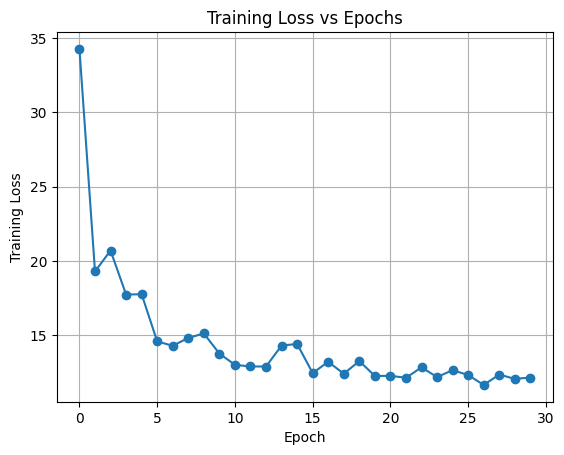

In [46]:
plt.plot(loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.savefig("TrainingvsLoss.pdf", format="pdf", bbox_inches='tight')
plt.show()
